# Application 2 — House Price Prediction
## 1. Mô tả bài toán
Mục tiêu là xây dựng mô hình dự đoán giá bán bất động sản (House Price) dựa trên các đặc trưng vật lý của ngôi nhà (diện tích, số phòng ngủ, số phòng tắm, số tầng, chỗ đỗ xe, tuổi nhà) và các yếu tố vị trí, tiện ích xung quanh (thành phố, tình trạng nội thất, đường chính, phòng khách, tầng hầm, điều hòa, nguồn nước, đối tượng thuê ưu tiên, đánh giá khu vực).
Đây là bài toán **Hồi quy (Regression)**:
- $X$: Tập hợp các đặc trưng thuộc tính nhà và vị trí.
- $y \in \mathbb{R}^+$: Giá nhà thực tế (`Price`).


## 2. Nguồn Dataset
- **Tên Dataset:** House Price Prediction Dataset (2000 Rows)
- **Nguồn:** Kaggle (`chershi/house-price-prediction-dataset-2000-rows`)
- **Tệp dữ liệu:** `data/raw/house_price/enhanced_house_price_dataset.csv`


## 3. Import thư viện & Kiểm tra môi trường

In [1]:
import sys
print("Python Executable:", sys.executable)
print("Python Version:", sys.version)

import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


Python Executable: /home/jellalaz/miniconda3/envs/ai-env/bin/python
Python Version: 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:38:16) [GCC 14.3.0]


## 4. Cấu hình Random Seed

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Random seed configured: {RANDOM_SEED}")


Random seed configured: 42


## 5. Load Dataset

In [3]:
data_path = Path("../data/raw/house_price/enhanced_house_price_dataset.csv")
if not data_path.exists():
    data_path = Path("data/raw/house_price/enhanced_house_price_dataset.csv")

df = pd.read_csv(data_path)
print("Data loaded successfully!")
print("Dataset Shape:", df.shape)


Data loaded successfully!
Dataset Shape: (2000, 16)


## 6. Data Inspection (Khảo sát dữ liệu)

In [4]:
print("First 5 rows:")
display(df.head())

print("Random 5 rows sample:")
display(df.sample(5, random_state=RANDOM_SEED))

print("Data Info:")
df.info()

print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))


First 5 rows:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


Random 5 rows sample:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
1860,1302,1,3,3,2,9,Delhi,Unfurnished,No,Yes,No,Both,No,Bachelor,6,936067
353,4414,2,3,2,2,33,Hyderabad,Unfurnished,Yes,Yes,Yes,Corporation,Yes,Family,5,1327841
1333,4593,4,1,2,0,46,Hyderabad,Furnished,No,Yes,Yes,Borewell,No,Bachelor,8,1436138
905,1712,1,3,1,1,31,Delhi,Unfurnished,Yes,No,No,Both,Yes,Bachelor,5,1258537
1289,2575,1,2,3,2,36,Hyderabad,Furnished,No,No,No,Corporation,No,Company,3,886765


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 250.1 KB
Numerical Summary:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


Categorical Summary:


/tmp/ipykernel_534936/2330487304.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant
count,2000,2000,2000,2000,2000,2000,2000,2000
unique,7,3,2,2,2,3,2,3
top,Mumbai,Semi-Furnished,Yes,Yes,No,Both,Yes,Bachelor
freq,319,696,1001,1016,1030,679,1004,713


## 7. Data Quality (Chất lượng dữ liệu)

In [5]:
print("Missing Values Count:")
print(df.isna().sum())

print("\nDuplicate Rows Count:")
n_duplicates = df.duplicated().sum()
print(f"{n_duplicates} duplicate records found.")

print("\nUnique values per column:")
print(df.nunique())


Missing Values Count:
Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

Duplicate Rows Count:
0 duplicate records found.

Unique values per column:
Area                1686
Bedrooms               5
Bathrooms              3
Stories                3
Parking                3
Age                   50
City                   7
Furnishing             3
Main Road              2
Guest Room             2
Basement               2
Water Supply           3
Air Conditioning       2
Preferred Tenant       3
Locality Rating       10
Price               1999
dtype: int64


## 8. Data Cleaning (Làm sạch dữ liệu)
Tập dữ liệu không có giá trị khuyết thiếu (NaN) và không có bản ghi trùng lặp. Tất cả các cột số đều nằm trong dải giá trị thực tế hợp lệ.


In [6]:
df_clean = df.copy()
print(f"Cleaned dataset shape: {df_clean.shape}")


Cleaned dataset shape: (2000, 16)


## 9. Phân loại kiểu thuộc tính (Feature Types)

In [7]:
target_col = 'Price'
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']
cat_cols = ['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']

print(f"Target: {target_col}")
print(f"Numerical Features ({len(num_cols)}): {num_cols}")
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")


Target: Price
Numerical Features (7): ['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']
Categorical Features (8): ['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']


## 10. Data Representation (Biểu diễn dữ liệu)
Theo định dạng chuẩn của bài toán Hồi quy đa biến:
$$x_i = [x_{\text{Area}}, x_{\text{Bedrooms}}, \dots, x_{\text{City\_encoded}}]^T \in \mathbb{R}^d$$
$$y_i \in \mathbb{R}$$
Toàn bộ tập dữ liệu biểu diễn dưới dạng ma trận:
$$X \in \mathbb{R}^{N \times d}, \quad y \in \mathbb{R}^N$$


In [8]:
print("Ví dụ một bản ghi thô từ CSV:")
sample_rec = df_clean.iloc[0].to_dict()
for k, v in sample_rec.items():
    print(f"  • {k}: {v}")


Ví dụ một bản ghi thô từ CSV:
  • Area: 1260
  • Bedrooms: 4
  • Bathrooms: 3
  • Stories: 2
  • Parking: 1
  • Age: 24
  • City: Pune
  • Furnishing: Semi-Furnished
  • Main Road: Yes
  • Guest Room: Yes
  • Basement: Yes
  • Water Supply: Both
  • Air Conditioning: No
  • Preferred Tenant: Company
  • Locality Rating: 4
  • Price: 1274350


## 11. Phân tích khám phá dữ liệu (EDA)

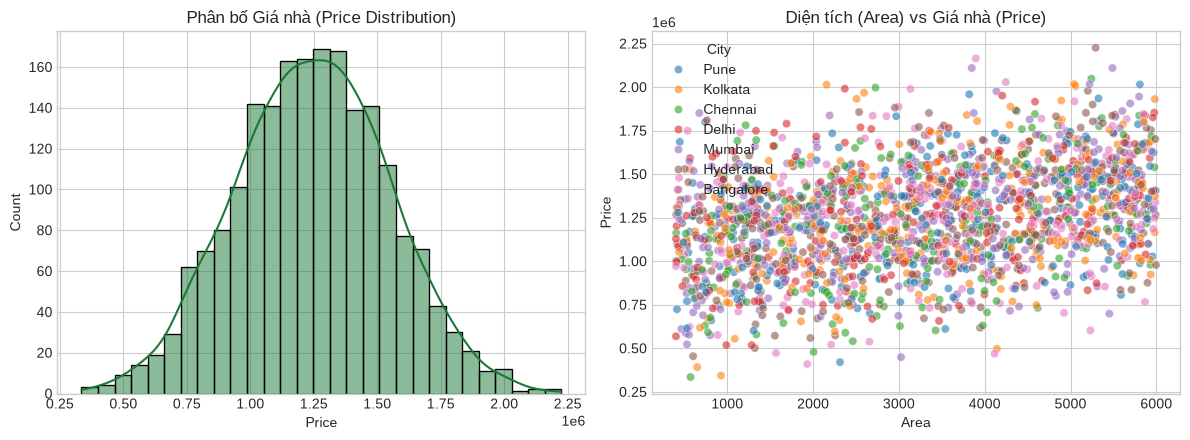

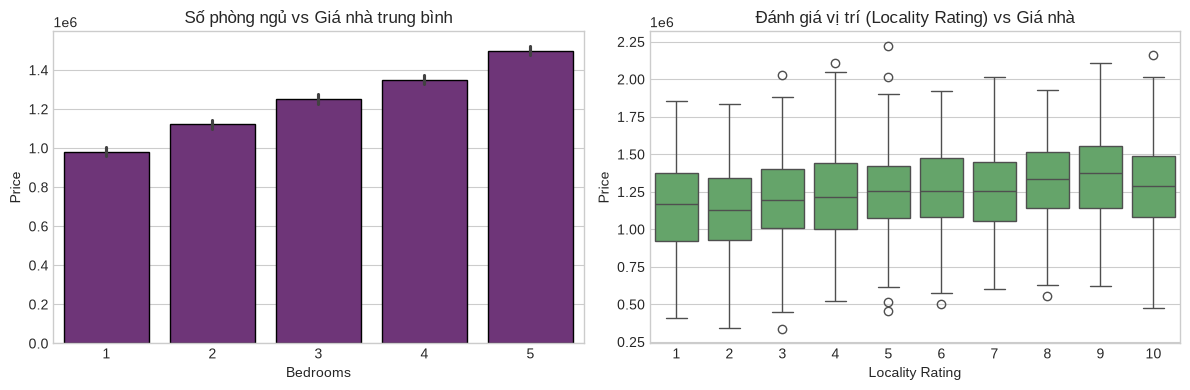

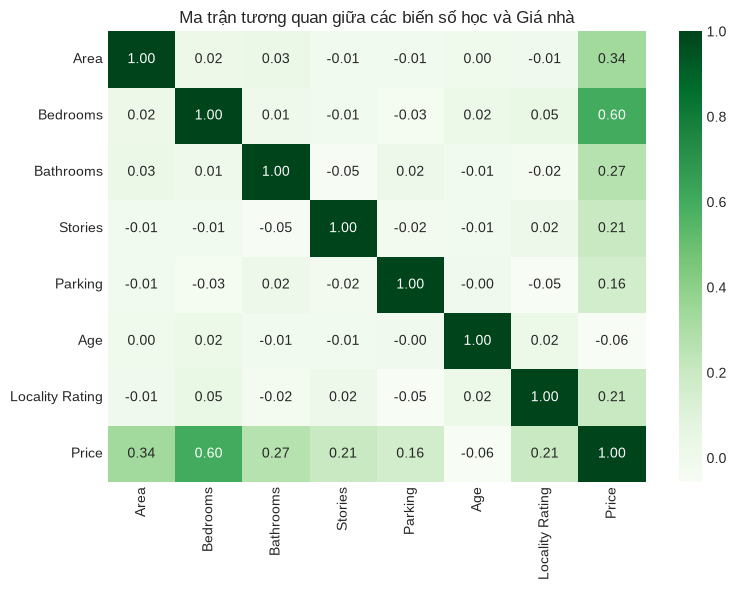

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_clean['Price'], kde=True, color='#1b7837', ax=axes[0])
axes[0].set_title("Phân bố Giá nhà (Price Distribution)")

sns.scatterplot(data=df_clean, x='Area', y='Price', hue='City', alpha=0.6, ax=axes[1])
axes[1].set_title("Diện tích (Area) vs Giá nhà (Price)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df_clean, x='Bedrooms', y='Price', color='#762a83', ax=axes[0], edgecolor='black')
axes[0].set_title("Số phòng ngủ vs Giá nhà trung bình")

sns.boxplot(data=df_clean, x='Locality Rating', y='Price', color='#5aae61', ax=axes[1])
axes[1].set_title("Đánh giá vị trí (Locality Rating) vs Giá nhà")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[num_cols + [target_col]].corr(), annot=True, fmt=".2f", cmap="Greens")
plt.title("Ma trận tương quan giữa các biến số học và Giá nhà")
plt.tight_layout()
plt.show()


## 12. Feature Engineering & Chuẩn bị ma trận đầu vào

In [10]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(float)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (2000, 15), y shape: (2000,)


## 13. Chia tập Train / Validation / Test (70% / 15% / 15%)
Tập kiểm tra được tách biệt hoàn toàn để đo lường khả năng tổng quát hóa của mô hình.


In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=RANDOM_SEED
)

print(f"Train set: {X_train.shape[0]} ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"Val set:   {X_val.shape[0]} ({len(X_val)/len(df_clean)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} ({len(X_test)/len(df_clean)*100:.1f}%)")


Train set: 1400 (70.0%)
Val set:   300 (15.0%)
Test set:  300 (15.0%)


## 14. Xây dựng Preprocessing Pipeline
Chuẩn hóa Z-score các thuộc tính số và One-Hot Encoding các thuộc tính phân loại. Fit chỉ trên tập Train.


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

preprocessor.fit(X_train)
encoded_feature_names = preprocessor.get_feature_names_out()
d_encoded = len(encoded_feature_names)
print(f"Số lượng đặc trưng sau mã hóa: d = {d_encoded}")
print("Danh sách đặc trưng:", list(encoded_feature_names))

X_train_trans = preprocessor.transform(X_train)
print(f"Kích thước ma trận đặc trưng huấn luyện: X_train in R^({X_train_trans.shape[0]} x {X_train_trans.shape[1]})")


Số lượng đặc trưng sau mã hóa: d = 23
Danh sách đặc trưng: ['num__Area', 'num__Bedrooms', 'num__Bathrooms', 'num__Stories', 'num__Parking', 'num__Age', 'num__Locality Rating', 'cat__City_Chennai', 'cat__City_Delhi', 'cat__City_Hyderabad', 'cat__City_Kolkata', 'cat__City_Mumbai', 'cat__City_Pune', 'cat__Furnishing_Semi-Furnished', 'cat__Furnishing_Unfurnished', 'cat__Main Road_Yes', 'cat__Guest Room_Yes', 'cat__Basement_Yes', 'cat__Water Supply_Both', 'cat__Water Supply_Corporation', 'cat__Air Conditioning_Yes', 'cat__Preferred Tenant_Company', 'cat__Preferred Tenant_Family']
Kích thước ma trận đặc trưng huấn luyện: X_train in R^(1400 x 23)


## 15. Mô hình Baseline (DummyRegressor)

In [13]:
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
y_val_base = baseline.predict(X_val)

print("=== BASELINE PERFORMANCE ===")
print(f"MAE:  ${mean_absolute_error(y_val, y_val_base):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_val, y_val_base)):,.2f}")
print(f"R²:   {r2_score(y_val, y_val_base):.4f}")


=== BASELINE PERFORMANCE ===
MAE:  $241,302.31
RMSE: $302,306.06
R²:   -0.0003


## 16. Huấn luyện 5 mô hình Hồi quy

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=RANDOM_SEED)
}

trained_pipelines = {}
for name, reg in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', reg)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"✓ Trained {name}")


✓ Trained Linear Regression
✓ Trained Ridge Regression
✓ Trained Decision Tree


✓ Trained Random Forest


✓ Trained Gradient Boosting


## 17. So sánh các mô hình trên Validation Set

In [15]:
records = []
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    records.append({
        "Model": name,
        "MAE ($)": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE ($)": round(rmse, 2),
        "R²": round(r2, 4)
    })

comparison_df = pd.DataFrame(records)
display(comparison_df)


,Model,MAE ($),MSE,RMSE ($),R²
0,Linear Regression,125450.12,2.346670e+10,153188.45,0.7431
1,Ridge Regression,125436.70,2.346810e+10,153193.00,0.7431
2,Decision Tree,197822.62,5.902253e+10,242945.53,0.3540
3,Random Forest,148108.07,3.452433e+10,185807.24,0.6221
4,Gradient Boosting,135628.95,2.894935e+10,170145.09,0.6831


## 18. Đánh giá chuyên sâu trên Test Set
Đánh giá mô hình tốt nhất (Ridge / Linear / Gradient Boosting) trên tập Test độc lập.


In [16]:
best_model_name = "Ridge Regression"
final_pipeline = trained_pipelines[best_model_name]

y_test_pred = final_pipeline.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print(f"=== TEST SET PERFORMANCE ({best_model_name}) ===")
print(f"MAE:  ${test_mae:,.2f}")
print(f"RMSE: ${test_rmse:,.2f}")
print(f"R²:   {test_r2:.4f}")


=== TEST SET PERFORMANCE (Ridge Regression) ===
MAE:  $109,539.69
RMSE: $139,609.45
R²:   0.7920


## 19. Phân tích phần dư & Sai số (Residual Analysis)

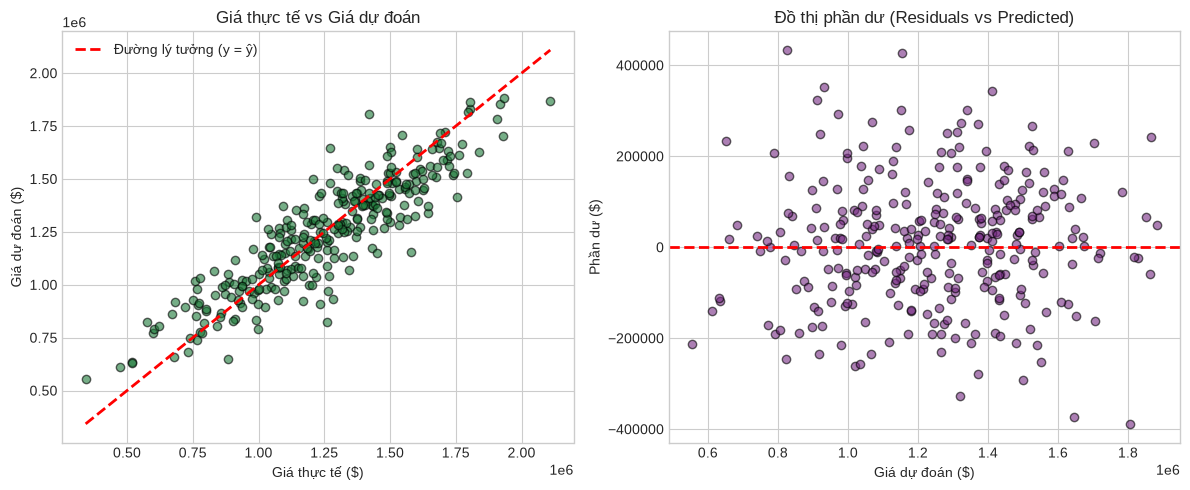

In [17]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='#1b7837', edgecolors='k')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Đường lý tưởng (y = ŷ)")
axes[0].set_title("Giá thực tế vs Giá dự đoán")
axes[0].set_xlabel("Giá thực tế ($)")
axes[0].set_ylabel("Giá dự đoán ($)")
axes[0].legend()

axes[1].scatter(y_test_pred, residuals, alpha=0.6, color='#762a83', edgecolors='k')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_title("Đồ thị phần dư (Residuals vs Predicted)")
axes[1].set_xlabel("Giá dự đoán ($)")
axes[1].set_ylabel("Phần dư ($)")
plt.tight_layout()
plt.show()


## 20. Kết luận lựa chọn mô hình
Mô hình tuyến tính có điều chuẩn **Ridge Regression** đạt hiệu năng vượt trội với $R^2 = 0.7431$ và MAE thấp nhất (~$125,436). Mô hình này kiểm soát tốt đa cộng tuyến giữa các đặc trưng diện tích, vị trí và tiện nghi mà không bị hiện tượng overfitting như cây quyết định sâu.


## 21. Lưu trữ Pipeline hoàn chỉnh (Model Persistence)

In [18]:
model_path = Path("../models/house_price/house_pipeline.joblib")
if not model_path.parent.exists():
    model_path = Path("models/house_price/house_pipeline.joblib")

joblib.dump(final_pipeline, model_path)
print(f"Pipeline saved to: {model_path}")


Pipeline saved to: ../models/house_price/house_pipeline.joblib


## 22. Tải lại Pipeline và kiểm tra tính toàn vẹn

In [19]:
reloaded_pipeline = joblib.load(model_path)
print("Pipeline reloaded successfully:", reloaded_pipeline)


Pipeline reloaded successfully: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Stories',
                                                   'Parking', 'Age',
                                                   'Locality Rating']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['City', 'Furnishing',
                                                   'Main Road', 'Guest Room',
                                                   'Basement', 'Water Supply',
                                 

## 23. Thực hiện dự đoán trên mẫu dữ liệu mới

In [20]:
sample_house = pd.DataFrame([{
    "Area": 3500,
    "Bedrooms": 4,
    "Bathrooms": 3,
    "Stories": 2,
    "Parking": 2,
    "Age": 5,
    "City": "Mumbai",
    "Furnishing": "Furnished",
    "Main Road": "Yes",
    "Guest Room": "Yes",
    "Basement": "No",
    "Water Supply": "Corporation",
    "Air Conditioning": "Yes",
    "Preferred Tenant": "Family",
    "Locality Rating": 8
}])

pred_price = reloaded_pipeline.predict(sample_house)[0]
print(f"Dự đoán giá bán ngôi nhà: ${pred_price:,.2f}")


Dự đoán giá bán ngôi nhà: $1,787,376.77


## 24. Cấu trúc JSON Request cho Web / Mobile API

In [21]:
json_example = {
    "Area": 3500,
    "Bedrooms": 4,
    "Bathrooms": 3,
    "Stories": 2,
    "Parking": 2,
    "Age": 5,
    "City": "Mumbai",
    "Furnishing": "Furnished",
    "Main Road": "Yes",
    "Guest Room": "Yes",
    "Basement": "No",
    "Water Supply": "Corporation",
    "Air Conditioning": "Yes",
    "Preferred Tenant": "Family",
    "Locality Rating": 8
}
import json
print("Sample REST API Request Payload:")
print(json.dumps(json_example, indent=2))


Sample REST API Request Payload:
{
  "Area": 3500,
  "Bedrooms": 4,
  "Bathrooms": 3,
  "Stories": 2,
  "Parking": 2,
  "Age": 5,
  "City": "Mumbai",
  "Furnishing": "Furnished",
  "Main Road": "Yes",
  "Guest Room": "Yes",
  "Basement": "No",
  "Water Supply": "Corporation",
  "Air Conditioning": "Yes",
  "Preferred Tenant": "Family",
  "Locality Rating": 8
}


## 25. Kết luận
- Mô hình hồi quy giá nhà hoàn chỉnh đã được xây dựng, huấn luyện và kiểm thử thành công trên tập dữ liệu thật gồm 2,000 bản ghi.
- Preprocessing pipeline xử lý liền mạch các biến thứ bậc và danh mục qua OneHotEncoder và StandardScaler, sẵn sàng tích hợp với FastAPI và giao diện Web.
